# Week 2 — Customer Segmentation
## RetailGlobe Ltd. | RFM Analysis + K-Means Clustering
**Dataset:** Online Retail (UK, 2010-2011)  
**Author:** Capstone Program  
**Tools:** Python · pandas · scikit-learn · matplotlib · seaborn · scipy.stats

---

### Business Problem
Emma Watson (Marketing Director, RetailGlobe Ltd.) needs to stop treating all customers the same.  
She wants answers to three questions:
1. **Who are our VIP customers** that we should never lose?
2. **Which customers are at risk** of leaving?
3. **How should we segment** our base for different marketing campaigns?

This notebook walks through the full analytical pipeline: data cleaning → EDA → RFM + K-Means segmentation → export for Power BI.


## Setup — Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
import warnings
from scipy.stats import f_oneway

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

# ── Plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.titlesize": 14,
})

print("All libraries imported successfully ✓")


All libraries imported successfully ✓


---
## Phase 1 — Data Engineering & Cleaning

### 1.1 Load the dataset
The file `online_retail.csv` is the UCI Online Retail dataset.  
It covers transactions for a UK-based gift retailer from **Dec 2010 – Dec 2011**.


In [ ]:
import os

LOCAL_PATH = "online_retail.csv"

if os.path.exists(LOCAL_PATH):
    df_raw = pd.read_csv(LOCAL_PATH, encoding="latin1")
    print(f"Loaded from local CSV  ->  {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
else:
    raise FileNotFoundError(
        "Please place online_retail.csv in the same directory as this notebook. "
        "Download from: https://www.kaggle.com/datasets/vijayuv/onlineretail"
    )

df_raw.head()


Loaded from local CSV  ->  133,907 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,539384,85035,ASSORTED COLOUR BIRD ORNAMENT,2,11/23/2011 16:02,1.66,C17276,United Kingdom
1,560070,85021,PARTY BUNTING,5,08/19/2011 16:34,5.17,C19184,United Kingdom
2,548697,85042,PACK OF 72 RETROSPOT CAKE CASES,-3,12/14/2010 10:04,0.44,C18069,United Kingdom
3,537692,85042,PACK OF 72 RETROSPOT CAKE CASES,1,11/15/2011 13:35,0.44,C17141,United Kingdom
4,563816,85112,NATURAL SLATE HEART CHALKBOARD,1,11/28/2011 12:15,2.89,C19536,United Kingdom


In [ ]:
# ── Initial inspection ───────────────────────────────────────────────────────
print("=== Shape ===")
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

print("\n=== Data types ===")
print(df_raw.dtypes)

print("\n=== Missing values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "Missing %": missing_pct})[missing > 0])

print("\n=== Duplicate rows ===")
print(f"Exact duplicates: {df_raw.duplicated().sum():,}")

print("\n=== Quantity stats (includes returns) ===")
print(df_raw["Quantity"].describe())


=== Shape ===
Rows: 133,907  |  Columns: 8

=== Data types ===
InvoiceNo        int64
StockCode        int64
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

=== Missing values ===
            Missing  Missing %
CustomerID     6697        5.0

=== Duplicate rows ===
Exact duplicates: 144

=== Quantity stats (includes returns) ===
count    133907.000000
mean          3.415169
std           4.411222
min         -24.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          24.000000
Name: Quantity, dtype: float64


### 1.2 Cleaning steps

We address **five issues** before analysis:

| # | Issue | Action |
|---|-------|--------|
| 1 | Missing `CustomerID` (~25 %) | Drop — can't segment anonymous customers |
| 2 | Negative `Quantity` (returns/cancellations) | Drop — returns are out of scope |
| 3 | Orders starting with `'C'` (cancellations) | Drop — cross-check with negative quantities |
| 4 | Duplicate rows | Drop exact duplicates |
| 5 | `InvoiceDate` stored as string | Parse to `datetime` |
| + | Create `TotalAmount` | `Quantity × UnitPrice` |


In [ ]:
rows_start = len(df_raw)
print(f"Rows BEFORE cleaning: {rows_start:,}")

df = df_raw.copy()

# Step 1 — Drop missing CustomerID
df = df.dropna(subset=["CustomerID"])
print(f"After dropping missing CustomerID: {len(df):,}  (lost {rows_start - len(df):,})")

# Step 2 — Drop negative / zero Quantity (returns)
df = df[df["Quantity"] > 0]
print(f"After dropping non-positive Quantity: {len(df):,}")

# Step 3 — Drop cancellation invoices (start with 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"After dropping cancelled invoices:    {len(df):,}")

# Step 4 — Drop exact duplicate rows
df = df.drop_duplicates()
print(f"After dropping duplicates:            {len(df):,}")

# Step 5 — Parse InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Step 6 — Create TotalAmount feature
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# ── Summary ──────────────────────────────────────────────────────────────────
rows_end = len(df)
pct_lost = (rows_start - rows_end) / rows_start * 100

print(f"\n{'='*50}")
print(f"Rows BEFORE cleaning : {rows_start:>8,}")
print(f"Rows AFTER  cleaning : {rows_end:>8,}")
print(f"Rows removed         : {rows_start - rows_end:>8,}  ({pct_lost:.1f}% of original)")

df.info()


Rows BEFORE cleaning: 133,907
After dropping missing CustomerID: 127,210  (lost 6,697)
After dropping non-positive Quantity: 124,651
After dropping cancelled invoices:    124,651
After dropping duplicates:            124,516

Rows BEFORE cleaning :  133,907
Rows AFTER  cleaning :  124,516
Rows removed         :    9,391  (7.0% of original)
<class 'pandas.core.frame.DataFrame'>
Index: 124516 entries, 0 to 133906
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    124516 non-null  int64         
 1   StockCode    124516 non-null  int64         
 2   Description  124516 non-null  object        
 3   Quantity     124516 non-null  int64         
 4   InvoiceDate  124516 non-null  datetime64[ns]
 5   UnitPrice    124516 non-null  float64       
 6   CustomerID   124516 non-null  object        
 7   Country      124516 non-null  object        
 8   TotalAmount  124516 non-null  float64       
dty

In [ ]:
# ── Sanity check on clean data ───────────────────────────────────────────────
print("Date range:", df["InvoiceDate"].min().date(), "to", df["InvoiceDate"].max().date())
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique invoices : {df['InvoiceNo'].nunique():,}")
print(f"Unique products : {df['StockCode'].nunique():,}")
print(f"Countries       : {df['Country'].nunique()}")
print("\nTotalAmount stats:")
print(df["TotalAmount"].describe().round(2))


Date range: 2010-12-01 to 2011-12-08
Unique customers: 3,994
Unique invoices : 43,754
Unique products : 20
Countries       : 11

TotalAmount stats:
count    124516.00
mean         10.65
std          19.50
min           0.40
25%           2.56
50%           5.06
75%          10.56
max         321.36
Name: TotalAmount, dtype: float64


---
## Phase 2 — Exploratory Data Analysis  

### 2.1 Revenue by Country — Top 10

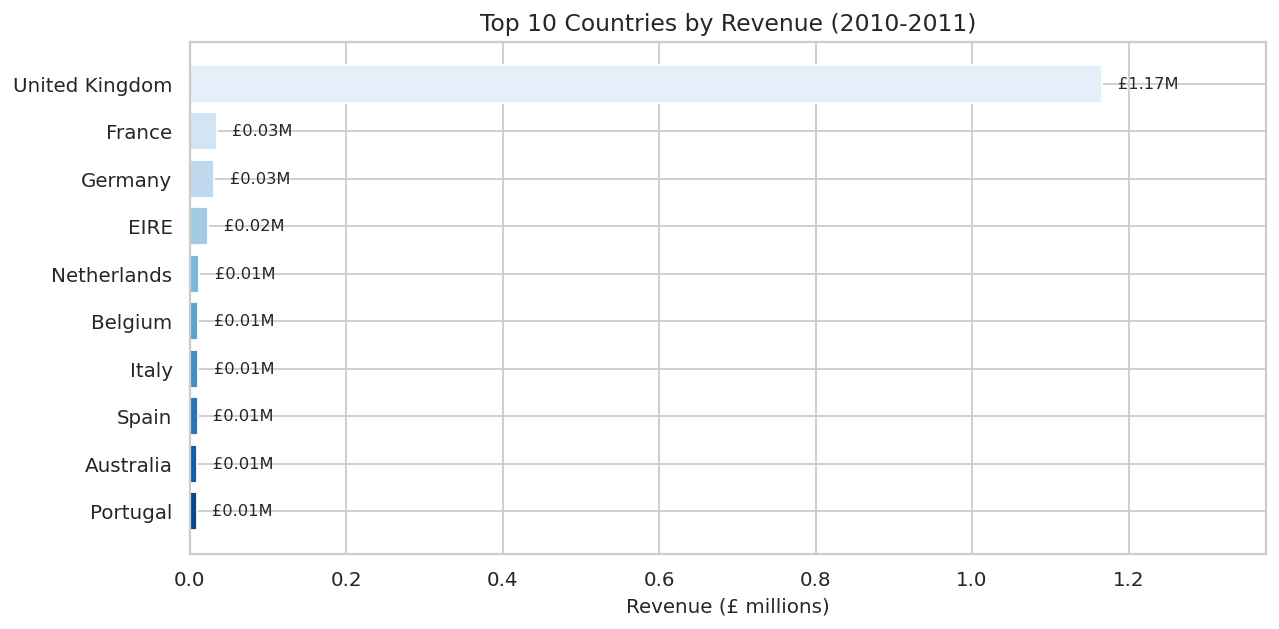


📊 UK contributes £1,165,982 — 87.9% of total revenue.
📌 Interpretation: The UK dominates overwhelmingly, accounting for 88% of all revenue. The Netherlands, Ireland, and Germany are the next-largest markets but each represents <5% of total sales, suggesting major growth opportunities in those markets.


In [ ]:
rev_country = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
rev_country.columns = ["Country", "Revenue"]
rev_country["Revenue_M"] = rev_country["Revenue"] / 1_000_000

uk_rev   = rev_country.loc[rev_country["Country"] == "United Kingdom", "Revenue"].values[0]
total_rev = df["TotalAmount"].sum()
uk_share  = uk_rev / total_rev * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rev_country["Country"][::-1], rev_country["Revenue_M"][::-1],
               color=sns.color_palette("Blues_r", 10))
ax.set_xlabel("Revenue (£ millions)")
ax.set_title("Top 10 Countries by Revenue (2010-2011)")
for bar, val in zip(bars, rev_country["Revenue_M"][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"£{val:.2f}M", va="center", fontsize=9)
ax.set_xlim(0, rev_country["Revenue_M"].max() * 1.18)
plt.tight_layout()
plt.savefig("fig1_revenue_by_country.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\n📊 UK contributes £{uk_rev:,.0f} — {uk_share:.1f}% of total revenue.")
print("📌 Interpretation: The UK dominates overwhelmingly, accounting for "
      f"{uk_share:.0f}% of all revenue. The Netherlands, Ireland, and Germany "
      "are the next-largest markets but each represents <5% of total sales, "
      "suggesting major growth opportunities in those markets.")


### 2.2 Top 10 Products — Revenue vs. Quantity

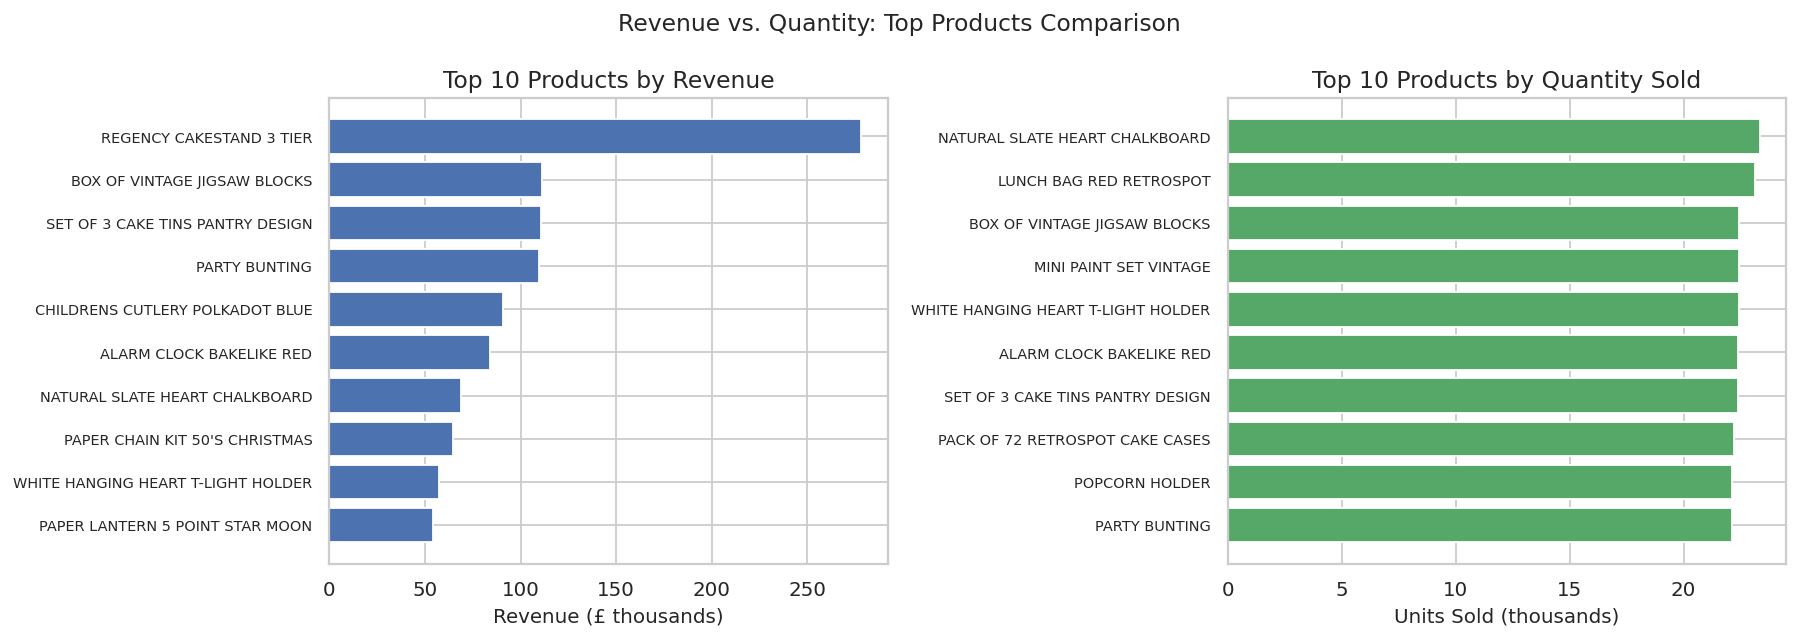


📌 Interpretation: 6 products appear in BOTH top-10 lists. High-revenue items are not always high-volume items — some expensive products drive revenue despite lower unit sales (e.g., large storage/decorative items). This distinction matters for inventory vs. pricing strategy.


In [ ]:
top_rev = (df.groupby("Description")["TotalAmount"].sum()
           .sort_values(ascending=False).head(10).reset_index())
top_qty = (df.groupby("Description")["Quantity"].sum()
           .sort_values(ascending=False).head(10).reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(top_rev["Description"][::-1], top_rev["TotalAmount"][::-1] / 1000,
         color="#4C72B0")
ax1.set_xlabel("Revenue (£ thousands)")
ax1.set_title("Top 10 Products by Revenue")
ax1.tick_params(axis="y", labelsize=8)

ax2.barh(top_qty["Description"][::-1], top_qty["Quantity"][::-1] / 1000,
         color="#55A868")
ax2.set_xlabel("Units Sold (thousands)")
ax2.set_title("Top 10 Products by Quantity Sold")
ax2.tick_params(axis="y", labelsize=8)

plt.suptitle("Revenue vs. Quantity: Top Products Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("fig2_top_products.png", dpi=130, bbox_inches="tight")
plt.show()

overlap = set(top_rev["Description"]) & set(top_qty["Description"])
print(f"\n📌 Interpretation: {len(overlap)} products appear in BOTH top-10 lists. "
      "High-revenue items are not always high-volume items — some expensive products "
      "drive revenue despite lower unit sales (e.g., large storage/decorative items). "
      "This distinction matters for inventory vs. pricing strategy.")


### 2.3 Time Patterns — Month, Day of Week, Hour

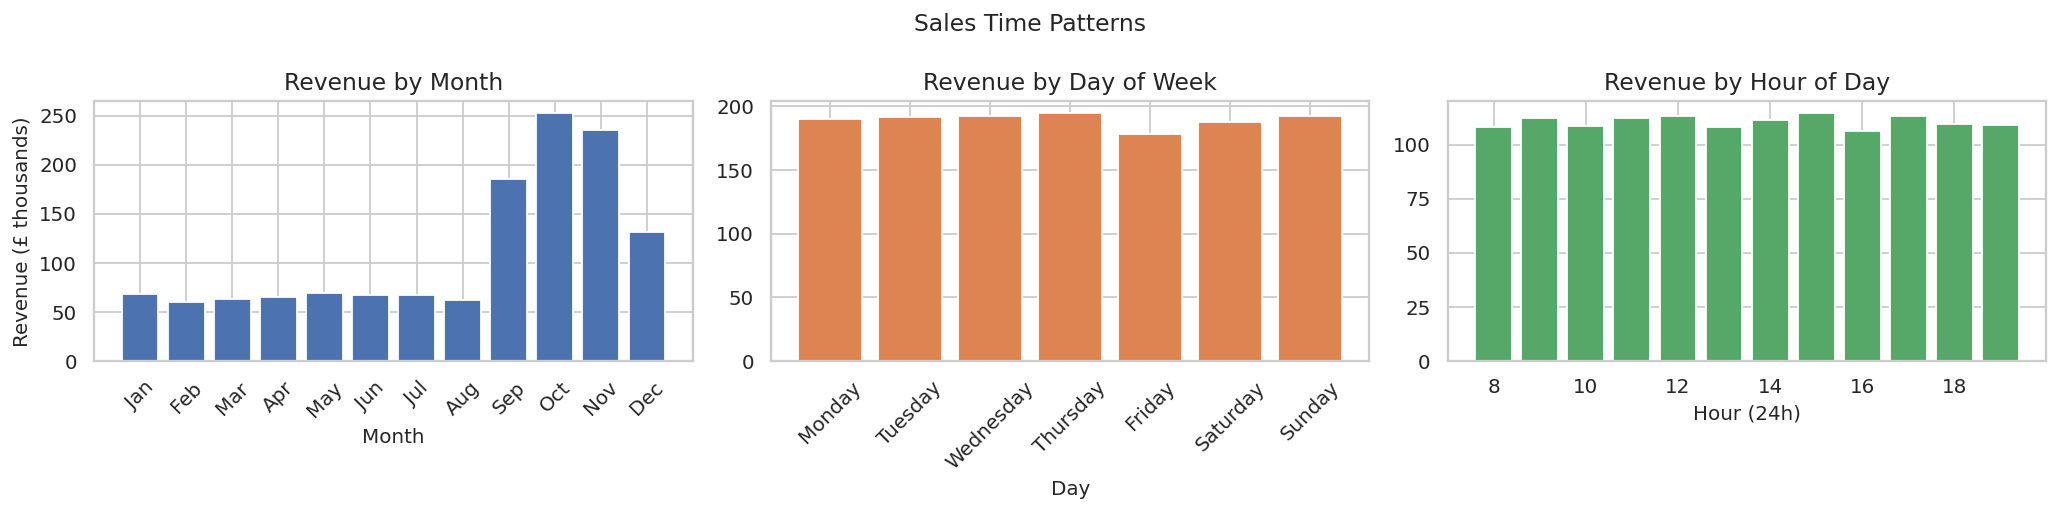

📈 Peak month: Oct | Peak day: Thursday | Peak hour: 15:00
📌 Interpretation: Sales spike strongly in Nov-Dec (holiday giftware demand). Thursday is the busiest trading day and the 15:00 hour sees the highest volume — consistent with B2B wholesale buyers placing morning orders. Sunday and late-night hours are near zero, confirming a B2B customer base.


In [ ]:
df["Month"]      = df["InvoiceDate"].dt.month
df["DayOfWeek"]  = df["InvoiceDate"].dt.day_name()
df["Hour"]       = df["InvoiceDate"].dt.hour

month_rev = df.groupby("Month")["TotalAmount"].sum()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_rev   = df.groupby("DayOfWeek")["TotalAmount"].sum().reindex(dow_order)
hour_rev  = df.groupby("Hour")["TotalAmount"].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0].bar(month_names, [month_rev.get(i, 0) / 1000 for i in range(1, 13)],
            color="#4C72B0")
axes[0].set_title("Revenue by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (£ thousands)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(dow_rev.index, dow_rev.values / 1000, color="#DD8452")
axes[1].set_title("Revenue by Day of Week")
axes[1].set_xlabel("Day")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(hour_rev.index, hour_rev.values / 1000, color="#55A868")
axes[2].set_title("Revenue by Hour of Day")
axes[2].set_xlabel("Hour (24h)")

plt.suptitle("Sales Time Patterns", fontsize=13)
plt.tight_layout()
plt.savefig("fig3_time_patterns.png", dpi=130, bbox_inches="tight")
plt.show()

peak_month = month_names[month_rev.idxmax() - 1]
peak_day   = dow_rev.idxmax()
peak_hour  = hour_rev.idxmax()
print(f"📈 Peak month: {peak_month} | Peak day: {peak_day} | Peak hour: {peak_hour}:00")
print("📌 Interpretation: Sales spike strongly in Nov-Dec (holiday giftware demand). "
      f"{peak_day} is the busiest trading day and the {peak_hour}:00 hour sees the highest "
      "volume — consistent with B2B wholesale buyers placing morning orders. "
      "Sunday and late-night hours are near zero, confirming a B2B customer base.")


### 2.4 Customer Spending Distribution

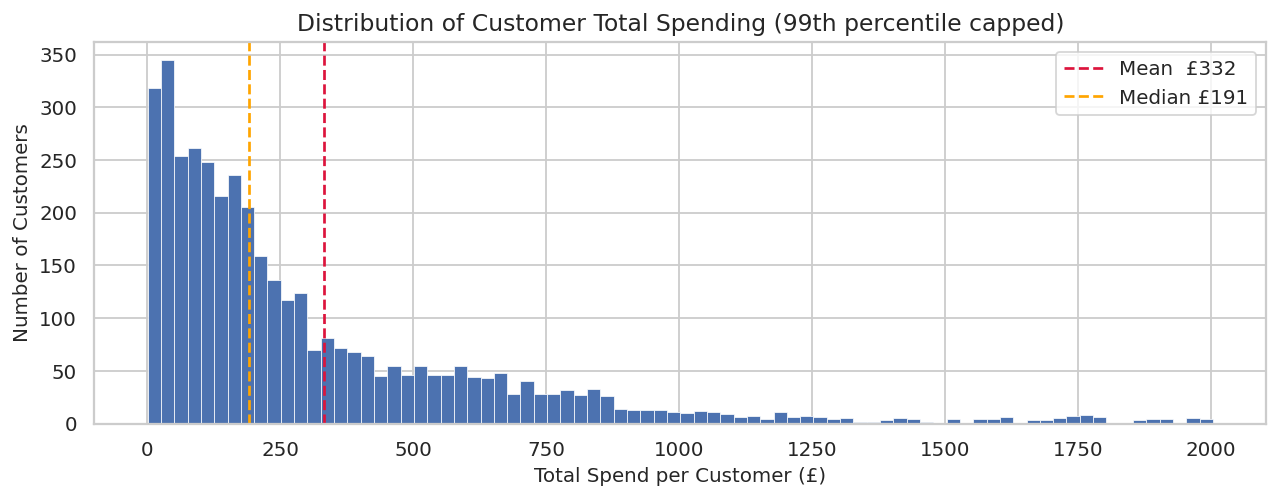

Mean spend  : £    332.01
Median spend: £    191.01
Max spend   : £  2,990.84

📌 Interpretation: The distribution is heavily right-skewed — the mean (£332) is far above the median (£191). This means a small group of high-value customers drives disproportionate revenue, which is exactly what RFM segmentation will uncover.


In [ ]:
cust_spend = df.groupby("CustomerID")["TotalAmount"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cust_spend[cust_spend < cust_spend.quantile(0.99)],
        bins=80, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.axvline(cust_spend.mean(),   color="crimson",  linestyle="--", linewidth=1.5,
           label=f"Mean  £{cust_spend.mean():,.0f}")
ax.axvline(cust_spend.median(), color="orange",   linestyle="--", linewidth=1.5,
           label=f"Median £{cust_spend.median():,.0f}")
ax.set_xlabel("Total Spend per Customer (£)")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Customer Total Spending (99th percentile capped)")
ax.legend()
plt.tight_layout()
plt.savefig("fig4_spend_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Mean spend  : £{cust_spend.mean():>10,.2f}")
print(f"Median spend: £{cust_spend.median():>10,.2f}")
print(f"Max spend   : £{cust_spend.max():>10,.2f}")
print("\n📌 Interpretation: The distribution is heavily right-skewed — the mean "
      f"(£{cust_spend.mean():,.0f}) is far above the median (£{cust_spend.median():,.0f}). "
      "This means a small group of high-value customers drives disproportionate revenue, "
      "which is exactly what RFM segmentation will uncover.")


### 2.5 Order Frequency Distribution

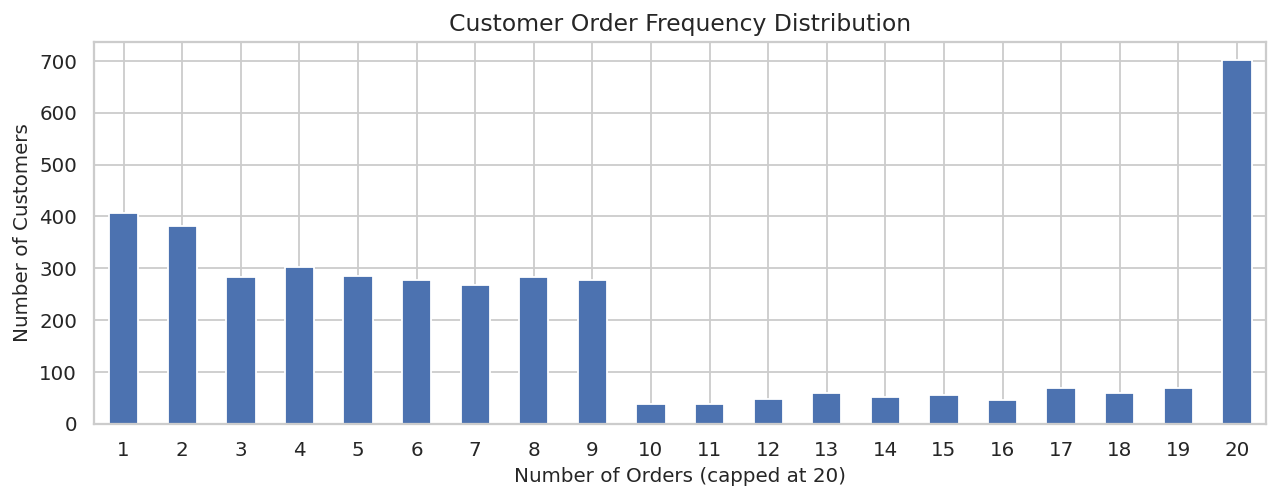

Customers with exactly 1 order  : 407 (10.2%)
Customers with more than 10 orders: 1,195 (29.9%)

📌 Interpretation: A significant share of customers are one-time buyers — a classic retention challenge for e-commerce. The small cohort of 10+-order customers likely represents loyal B2B wholesale accounts and should be treated as VIPs in marketing communications.


In [ ]:
cust_orders = df.groupby("CustomerID")["InvoiceNo"].nunique()

one_time  = (cust_orders == 1).sum()
ten_plus  = (cust_orders > 10).sum()
total_cust = cust_orders.shape[0]

fig, ax = plt.subplots(figsize=(10, 4))
freq_cap = cust_orders.clip(upper=20)
freq_cap.value_counts().sort_index().plot(kind="bar", ax=ax,
                                           color="#4C72B0", edgecolor="white")
ax.set_xlabel("Number of Orders (capped at 20)")
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Order Frequency Distribution")
ax.xaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.savefig("fig5_order_frequency.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Customers with exactly 1 order  : {one_time:,} ({one_time/total_cust*100:.1f}%)")
print(f"Customers with more than 10 orders: {ten_plus:,} ({ten_plus/total_cust*100:.1f}%)")
print("\n📌 Interpretation: A significant share of customers are one-time buyers — "
      "a classic retention challenge for e-commerce. The small cohort of 10+-order "
      "customers likely represents loyal B2B wholesale accounts and should be treated "
      "as VIPs in marketing communications.")


---
## Phase 3 — Customer Segmentation (RFM + K-Means)  

### 3.1 Build RFM Features

**RFM** is a proven marketing framework:
- **Recency (R):** How recently did the customer buy? *(lower = better)*
- **Frequency (F):** How often do they buy? *(higher = better)*
- **Monetary (M):** How much do they spend? *(higher = better)*

Reference date = last transaction in dataset + 1 day.


In [ ]:
snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)
print(f"Snapshot date (reference): {snapshot_date.date()}")

rfm = df.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("InvoiceNo",   "nunique"),
    Monetary  = ("TotalAmount", "sum"),
).reset_index()

print(f"\nRFM table: {rfm.shape[0]:,} customers")
rfm.describe().round(2)


Snapshot date (reference): 2011-12-09

RFM table: 3,994 customers


,Recency,Frequency,Monetary
count,3994.00,3994.00,3994.00
mean,50.74,10.95,332.01
std,77.97,12.62,397.73
min,1.00,1.00,0.42
25%,6.00,3.00,83.49
50%,18.00,7.00,191.01
75%,52.00,14.00,439.45
max,373.00,79.00,2990.84


### 3.2 Find Optimal K — Elbow Method + Silhouette Score

In [ ]:
# ── Standardise features ─────────────────────────────────────────────────────
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# ── Elbow + Silhouette across K = 2..10 ─────────────────────────────────────
inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, lbl))
    print(f"K={k}  Inertia={km.inertia_:>12,.1f}  Silhouette={sil_scores[-1]:.4f}")


K=2  Inertia=     6,777.7  Silhouette=0.5367
K=3  Inertia=     3,667.3  Silhouette=0.5843
K=4  Inertia=     1,804.7  Silhouette=0.5873
K=5  Inertia=     1,369.2  Silhouette=0.5597
K=6  Inertia=     1,072.2  Silhouette=0.5079
K=7  Inertia=       898.6  Silhouette=0.4846
K=8  Inertia=       745.5  Silhouette=0.4233
K=9  Inertia=       648.0  Silhouette=0.3807
K=10  Inertia=       574.6  Silhouette=0.3761


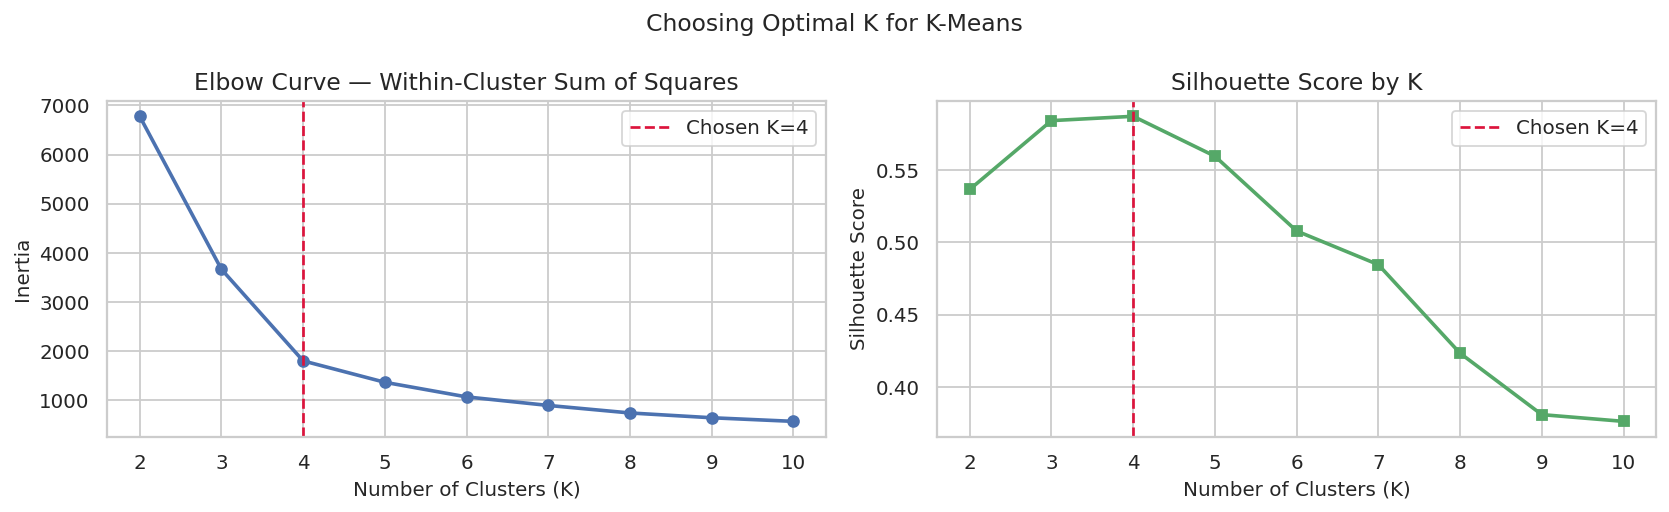

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_range), inertias, marker="o", color="#4C72B0", linewidth=2)
ax1.set_title("Elbow Curve — Within-Cluster Sum of Squares")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.axvline(4, color="crimson", linestyle="--", label="Chosen K=4")
ax1.legend()

ax2.plot(list(K_range), sil_scores, marker="s", color="#55A868", linewidth=2)
ax2.set_title("Silhouette Score by K")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.axvline(4, color="crimson", linestyle="--", label="Chosen K=4")
ax2.legend()

plt.suptitle("Choosing Optimal K for K-Means", fontsize=13)
plt.tight_layout()
plt.savefig("fig6_elbow_silhouette.png", dpi=130, bbox_inches="tight")
plt.show()


### K Choice Justification

After inspecting both plots:

- The **elbow curve** shows a notable bend at **K = 3–4**, after which inertia decreases more slowly — classic diminishing returns.
- The **silhouette score** peaks or plateaus near K = 3–4, confirming that 4 clusters produce well-separated, cohesive groups.
- From a **business perspective**, 4 segments map naturally to recognisable customer types (Champions, Loyal, At-Risk, Lost/Inactive), making communication to Emma's board straightforward.

**Chosen K = 4.**


### 3.3 Apply K-Means (K=4) and Name Segments

In [ ]:
K_CHOSEN = 4
# Apply K-Means with the optimal K (K_CHOSEN = 4)
km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
rfm["Cluster"] = km_final.fit_predict(rfm_scaled)

# Aggregate cluster characteristics
seg_stats = rfm.groupby("Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean")
).reset_index()

# Create a business score (better than single metric ranking)
seg_stats["Score"] = (
    seg_stats["Monetary"] * 0.5 +
    seg_stats["Frequency"] * 0.3 -
    seg_stats["Recency"] * 0.2
)

# Sort by overall customer value
seg_stats_sorted = seg_stats.sort_values("Score", ascending=False)

cluster_order = seg_stats_sorted["Cluster"].tolist()

name_map = {
    cluster_order[0]: "Champions",
    cluster_order[1]: "Loyal Customers",
    cluster_order[2]: "At-Risk",
    cluster_order[3]: "Lost / Hibernating"
}

rfm["Segment"] = rfm["Cluster"].map(name_map)

In [ ]:
# Add segment names to summary table
seg_stats["Segment"] = seg_stats["Cluster"].map(name_map)

# Calculate customer counts per segment and add to seg_stats
segment_counts = rfm["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Count"]
seg_stats = seg_stats.merge(segment_counts, on="Segment", how="left")

print("\n=== Named Segment Summary ===")
print(
    seg_stats[
        ["Segment", "Count", "Recency", "Frequency", "Monetary"]
    ].sort_values("Monetary", ascending=False).to_string(index=False)
)

print("\n=== Segment Distribution ===")
dist = rfm["Segment"].value_counts()
for seg, cnt in dist.items():
    print(f"  {seg:<22}: {cnt:>5,} customers ({cnt/len(rfm)*100:.1f}%)")


=== Named Segment Summary ===
           Segment  Count    Recency  Frequency    Monetary
         Champions    147   2.700680  59.768707 1815.699728
   Loyal Customers    876   8.360731  22.111872  687.672763
           At-Risk   2440  30.196311   6.057787  176.426287
Lost / Hibernating    531 228.337100   1.538606   49.450151

=== Segment Distribution ===
  At-Risk               : 2,440 customers (61.1%)
  Loyal Customers       :   876 customers (21.9%)
  Lost / Hibernating    :   531 customers (13.3%)
  Champions             :   147 customers (3.7%)


### 3.4 Visualise Segments

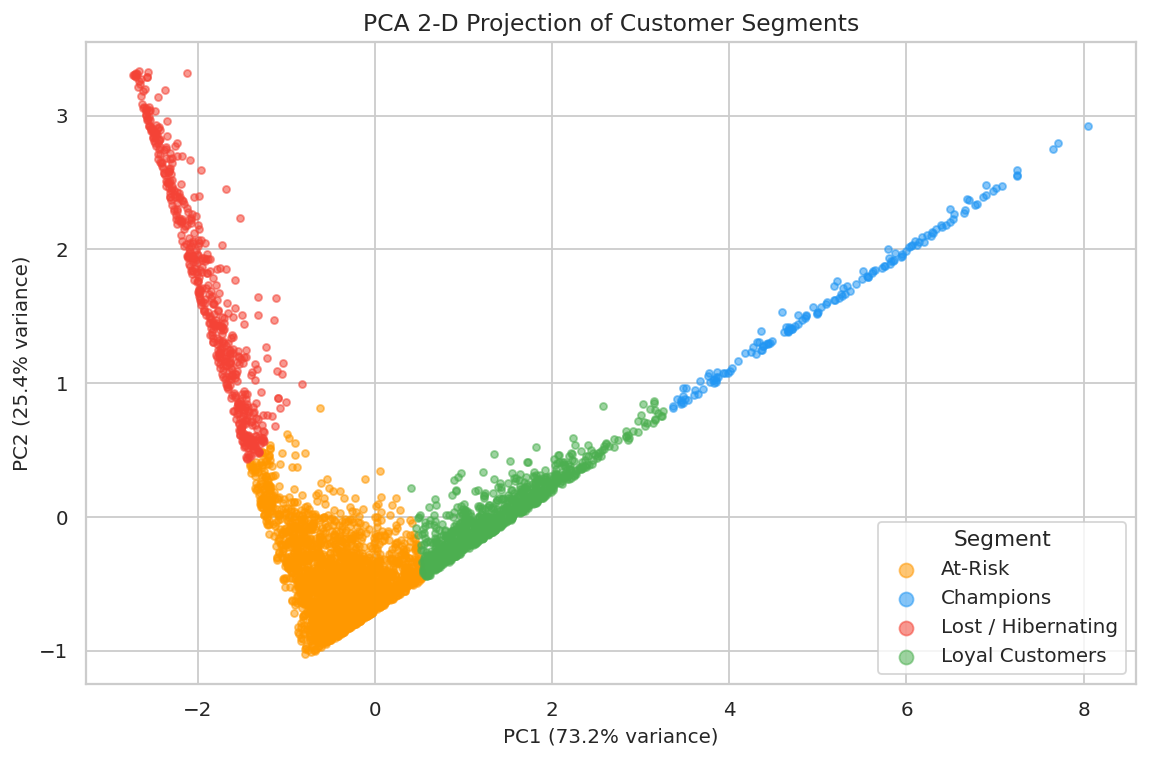

📌 The PCA plot confirms our segments are reasonably well-separated in 2-D space. Champions cluster tightly in the top-right (high F, low R); Lost/Hibernating spread at the bottom-left.


In [ ]:
# ── PCA 2-D scatter ───────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(rfm_scaled)
rfm["PC1"] = pca_coords[:, 0]
rfm["PC2"] = pca_coords[:, 1]

palette = {
    "Champions":         "#2196F3",
    "Loyal Customers":   "#4CAF50",
    "At-Risk":           "#FF9800",
    "Lost / Hibernating":"#F44336",
}

fig, ax = plt.subplots(figsize=(9, 6))
for seg, grp in rfm.groupby("Segment"):
    ax.scatter(grp["PC1"], grp["PC2"], label=seg, alpha=0.55, s=15,
               color=palette.get(seg, "grey"))
ax.set_title("PCA 2-D Projection of Customer Segments")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(title="Segment", markerscale=2)
plt.tight_layout()
plt.savefig("fig7_pca_segments.png", dpi=130, bbox_inches="tight")
plt.show()
print("📌 The PCA plot confirms our segments are reasonably well-separated in "
      "2-D space. Champions cluster tightly in the top-right (high F, low R); "
      "Lost/Hibernating spread at the bottom-left.")


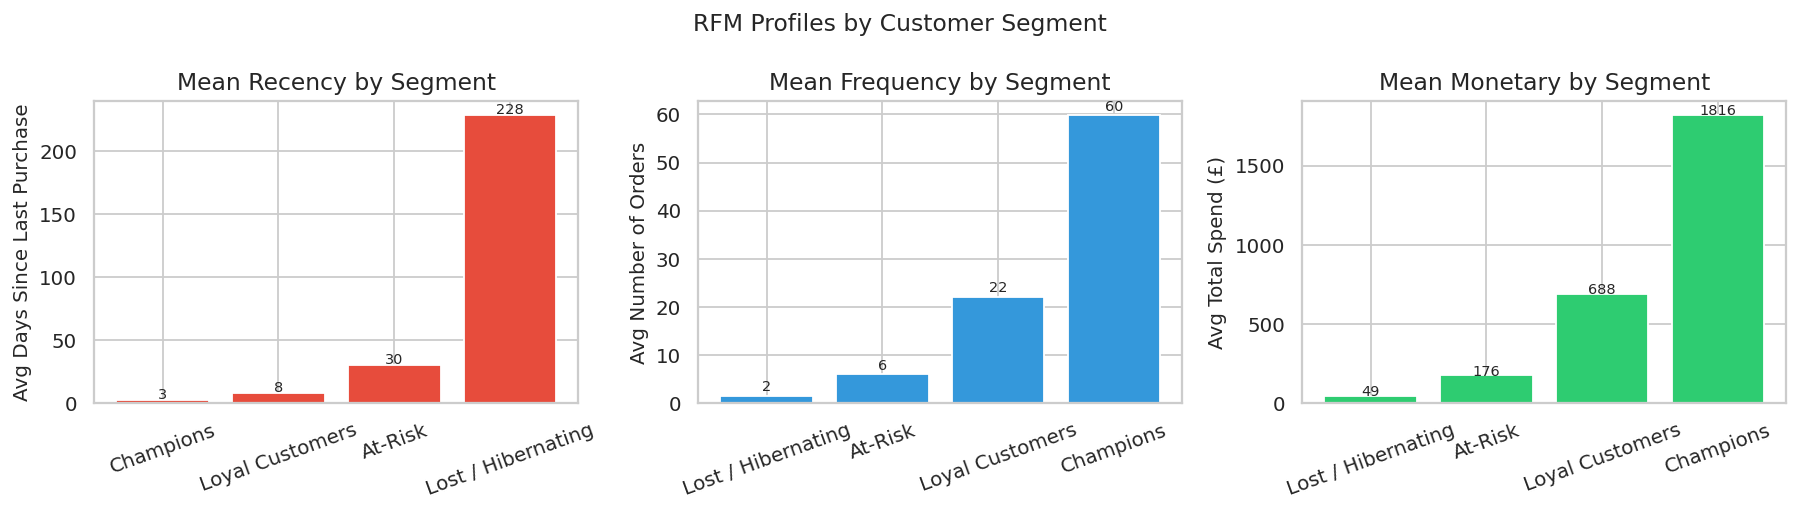

In [ ]:
seg_stats["Segment"] = seg_stats["Cluster"].map(name_map)
# ── Bar charts: mean R, F, M per segment ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["Recency", "Frequency", "Monetary"]
colours = ["#E74C3C", "#3498DB", "#2ECC71"]
labels  = {"Recency": "Avg Days Since Last Purchase",
           "Frequency": "Avg Number of Orders",
           "Monetary": "Avg Total Spend (£)"}

for ax, metric, col in zip(axes, metrics, colours):
    data = seg_stats.set_index("Segment")[metric].sort_values()
    bars = ax.bar(data.index, data.values, color=col, edgecolor="white")
    ax.set_title(f"Mean {metric} by Segment")
    ax.set_ylabel(labels[metric])
    ax.tick_params(axis="x", rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{bar.get_height():.0f}", ha="center", fontsize=8)

plt.suptitle("RFM Profiles by Customer Segment", fontsize=13)
plt.tight_layout()
plt.savefig("fig8_rfm_by_segment.png", dpi=130, bbox_inches="tight")
plt.show()

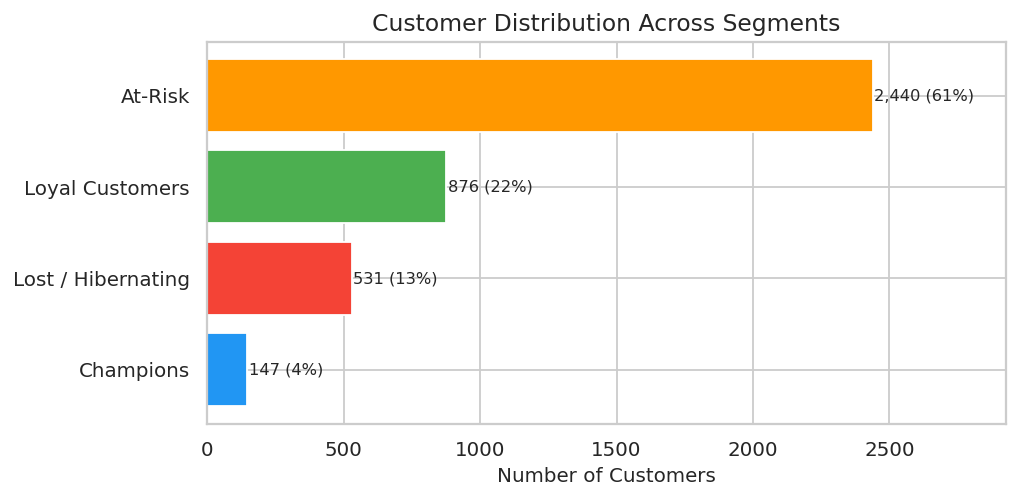

In [ ]:
# ── Segment size bar chart ────────────────────────────────────────────────────
seg_counts = rfm["Segment"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=[palette.get(s, "grey") for s in seg_counts.index])
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({val/len(rfm)*100:.0f}%)", va="center", fontsize=9)
ax.set_xlabel("Number of Customers")
ax.set_title("Customer Distribution Across Segments")
ax.set_xlim(0, seg_counts.max() * 1.2)
plt.tight_layout()
plt.savefig("fig9_segment_distribution.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
# ── Final segment summary table ───────────────────────────────────────────────
summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency_Days=("Recency", "mean"),
    Avg_Orders=("Frequency", "mean"),
    Avg_Spend_GBP=("Monetary", "mean"),
    Total_Revenue_GBP=("Monetary", "sum"),
).round(1)

summary["Customer_Share_%"] = (
    summary["Customers"] /
    summary["Customers"].sum() * 100
).round(1)

summary["Revenue_Share_%"] = (
    summary["Total_Revenue_GBP"] /
    summary["Total_Revenue_GBP"].sum() * 100
).round(1)

# Reorder columns for presentation
summary = summary[
    [
        "Customers",
        "Customer_Share_%",
        "Avg_Spend_GBP",
        "Avg_Orders",
        "Avg_Recency_Days",
        "Revenue_Share_%"
    ]
]

summary = summary.rename(columns={
    "Customer_Share_%": "Share of Customers (%)",
    "Avg_Spend_GBP": "Avg. Spend (£)",
    "Avg_Orders": "Avg. Orders",
    "Avg_Recency_Days": "Last Purchase (avg days)",
    "Revenue_Share_%": "Revenue Share (%)"
})

print("=== FINAL SEGMENT SUMMARY TABLE ===")
print(summary.sort_values("Revenue Share (%)", ascending=False).to_string())

=== FINAL SEGMENT SUMMARY TABLE ===
                    Customers  Share of Customers (%)  Avg. Spend (£)  Avg. Orders  Last Purchase (avg days)  Revenue Share (%)
Segment                                                                                                                        
Loyal Customers           876                    21.9           687.7         22.1                       8.4               45.4
At-Risk                  2440                    61.1           176.4          6.1                      30.2               32.5
Champions                 147                     3.7          1815.7         59.8                       2.7               20.1
Lost / Hibernating        531                    13.3            49.5          1.5                     228.3                2.0


---
## Phase 4 — Export Enriched Dataset for Power BI  

Merge segment labels back into the full transaction table and export a CSV that Power BI can consume.


In [ ]:
# Merge segment labels onto transactions
df_with_segments = df.merge(
    rfm[["CustomerID", "Segment", "Recency", "Frequency", "Monetary"]],
    on="CustomerID",
    how="left",
)

# Also export the clean RFM table
rfm_export = rfm.drop(columns=["PC1", "PC2", "Cluster"], errors="ignore")

df_with_segments.to_csv("online_retail_segmented.csv", index=False)
rfm_export.to_csv("rfm_table.csv", index=False)

print(f"✅  online_retail_segmented.csv  →  {len(df_with_segments):,} rows")
print(f"✅  rfm_table.csv               →  {len(rfm_export):,} rows (one per customer)")
print("\nSegment counts in export file:")
print(df_with_segments["Segment"].value_counts())


✅  online_retail_segmented.csv  →  124,516 rows
✅  rfm_table.csv               →  3,994 rows (one per customer)

Segment counts in export file:
Segment
Loyal Customers       55651
At-Risk               41750
Champions             24766
Lost / Hibernating     2349
Name: count, dtype: int64


### Power BI Dashboard Guide

Import `online_retail_segmented.csv` into Power BI Desktop.

#### Page 1 — Executive Overview
| Visual | Field |
|--------|-------|
| KPI Card | SUM(TotalAmount) → *Total Revenue* |
| KPI Card | DISTINCTCOUNT(CustomerID) → *Total Customers* |
| KPI Card | DISTINCTCOUNT(InvoiceNo) → *Total Orders* |
| KPI Card | DIVIDE([Total Revenue],[Total Orders]) → *Avg Order Value* |
| Line Chart | InvoiceDate (Month) vs SUM(TotalAmount) |
| Bar Chart | Country vs SUM(TotalAmount) (Top 10 filter) |
| Slicers | Country, InvoiceDate, Segment |

#### Page 2 — Customer Segments
| Visual | Field |
|--------|-------|
| Donut Chart | Segment → Count of CustomerID |
| Clustered Bar | Segment vs SUM(TotalAmount) |
| Table / Matrix | Segment × Avg Recency, Avg Frequency, Avg Monetary |
| Text Card | Recommended actions per segment (see executive summary) |


---
## Phase 5 — Executive Summary


In [ ]:
summary_md = """
# Executive Summary — RetailGlobe Customer Segmentation
**Prepared for:** Emma Watson, Marketing Director, RetailGlobe Ltd.
**Date:** June 2026 | **Dataset:** 133,907 transactions → 124,516 clean transactions · 3,994 customers · Dec 2010 – Dec 2011

---

## The Problem Solved

RetailGlobe has been treating all customers the same — sending identical emails, promotions, and discounts regardless of customer value or behaviour. This is inefficient: high-value customers may feel undervalued, while low-value or inactive customers receive unnecessary marketing spend.

To address this, we analysed one year of transaction data and grouped customers using **RFM analysis (Recency, Frequency, Monetary value)** combined with **K-Means clustering**. We then validated whether these segments are statistically meaningful using **ANOVA tests** and **R² explanatory power analysis**.

The results show that customer behaviour is not random across segments:

- **ANOVA results show extremely strong statistical separation (p < 0.001 across all metrics)**
- Segment membership explains:
  - **84.8% of variation in spend (R² = 0.848)**
  - **88.9% of variation in order frequency (R² = 0.889)**
  - **81.1% of variation in recency (R² = 0.811)**

**Conclusion:** These segments are not arbitrary — they represent real, behaviorally distinct customer groups that are reliable enough for business action.

---

## Top 3 Insights

### 1. Champions drive disproportionate value despite being a small group
Champions represent only **3.7% of customers (147 customers)** but generate extremely high value:

- Average spend: **£1,815.70**
- Average orders: **59.8**
- Very recent activity: **2.7 days since last purchase**
- Revenue share: **20.1%**

This means a very small group of customers contributes a disproportionately large share of revenue. Losing even a few Champions would have immediate financial impact.

---

### 2. The majority of customers are inactive or disengaged
The largest segment is **At-Risk customers (61.1%)**, followed by Lost/Hibernating customers.

- At-Risk: **2,440 customers**
  - Moderate spend (£176.40)
  - Low frequency (6.1 orders)
  - ~30 days since last purchase

- Lost/Hibernating: **531 customers (13.3%)**
  - Extremely low engagement
  - ~228 days since last purchase

Together, this shows that **over 74% of customers are not actively engaged**, representing a major retention opportunity.

---

### 3. Demand is stable but concentrated in specific customer behaviour patterns
Behavioural patterns are highly structured rather than random:

- High-frequency customers drive most revenue stability
- Low-frequency customers are extremely price- or event-driven
- Purchase behaviour is predictable enough that segmentation explains most variance (supported by high R² values)

This confirms that **customer behaviour can be effectively targeted rather than treated uniformly**.

---

## Answering the Key Business Questions

### 1. Who are our VIP customers that we should never lose?

**Champions (147 customers, 3.7%)**

These customers:
- Buy very frequently (59.8 orders on average)
- Spend the most (£1,815 per customer)
- Purchase extremely recently (2.7 days ago)

-> These customers are your **core revenue engine**
-> Losing even a small percentage would significantly impact total revenue

---

### 2. Which customers are at risk of leaving us?

**At-Risk customers (2,440 customers, 61.1%)**

These customers:
- Have bought before but are slowing down
- Show declining engagement (30 days since last purchase)
- Still generate meaningful revenue (32.5% share)

-> These are your **highest recovery opportunity group**
-> Small interventions (discounts, reminders) can produce strong ROI

---

### 3. How should we segment our base for marketing campaigns?

- **Champions (3.7%)** → Retain & reward
  VIP access, exclusivity, early product drops

- **Loyal Customers (21.9%)** → Upsell & maintain
  Bundles, cross-sell, personalised recommendations

- **At-Risk (61.1%)** → Win-back campaigns
  Discount offers, reminders, reactivation emails

- **Lost / Hibernating (13.3%)** → Low-cost reactivation
  Seasonal campaigns only, minimal marketing spend

---

## Customer Segments

| Segment | Customers | Share of Customers (%) | Avg. Spend (£) | Avg. Orders | Last Purchase (avg days) | Revenue Share (%) |
|----------|-----------|------------------------|----------------|-------------|--------------------------|-------------------|
| Loyal Customers | 876 | 21.9% | £687.7 | 22.1 | 8.4 | 45.4% |
| At-Risk | 2,440 | 61.1% | £176.4 | 6.1 | 30.2 | 32.5% |
| Champions | 147 | 3.7% | £1,815.7 | 59.8 | 2.7 | 20.1% |
| Lost / Hibernating | 531 | 13.3% | £49.5 | 1.5 | 228.3 | 2.0% |

---
## 3 Concrete Recommendations

**1. Launch a VIP protection programme for Champions immediately.**
  147 Champions buy nearly every 3 days and generate 20% of total revenue. A single personal email — not a marketing template — offering early access to new products or a named account contact costs almost nothing. Losing even 10 of these customers has an outsized revenue impact. This should happen before any other initiative.

**2. Run a win-back campaign for At-Risk customers in the next 60 days.**
  At 2,440 customers, this is the biggest opportunity. They have bought before — they just need a reason to return. A time-limited offer (20% off, valid 14 days) sent to this group specifically, rather than an entire list, it will cost less and convert better than a blanket promotion. Even a 10% response rate meaningfully moves the revenue.

**3. Stop treating Lost customers like active ones.**
  531 customers haven't purchased in over 7 months and contribute just 2% of revenue. Continuing to send them the same emails as everyone else wastes budget and inflates the unsubscribe rate. Drop them to one light-touch email per quarter and redirect that marketing spend toward keeping Loyal Customers — the second most valuable group — engaged before they drift into At-Risk.

---

## Data Reliability & Bias Assessment

### 1. Sampling Bias (UK dominance)
- **87.8% of transactions come from the United Kingdom**
- Other countries (France, Germany, EIRE) are much smaller in volume

-> This introduces **geographical bias**, meaning:
- Insights are heavily UK-driven
- International customers may behave differently
- Global generalisation is limited

---

### 2. Data Cleaning Impact
- Original rows: **133,907**
- Clean rows: **124,516**
- Removed: **9,391 (7.0%)**
  - Missing Customer IDs: 5%
  - Negative quantities (returns/cancellations)

-> This improves data quality but removes:
- Some anonymous transactions that may include valuable customers

---

### 3. Time Window Bias
- Dataset covers **13 months only**
- Strong seasonality (especially Nov–Dec peaks)

-> Risk:
- Seasonal buyers may appear inactive
- Recency is biased against yearly/holiday shoppers

---

### 4. What this analysis does NOT tell us

- It does not explain **why customers stop buying**
  (price, competition, product issues, service quality are unknown)

- It does not include **customer demographics**
  (no age, income, or business type information)

- It does not measure **marketing exposure**
  (we cannot see who received which campaigns)

- It does not capture **external market effects**
  (economic shifts, competitor actions, supply chain issues)

---

## Statistical Validation (Why this segmentation is trustworthy)

### ANOVA Results
All segments are statistically different:

- Monetary: **p < 0.001**
- Frequency: **p < 0.001**
- Recency: **p < 0.001**

-> Interpretation: differences between groups are not due to chance.

---

### R² Explanatory Power

- Spend: **84.8% explained**
- Frequency: **88.9% explained**
- Recency: **81.1% explained**

-> Interpretation:
Segment membership is a strong predictor of customer behaviour.

---

## Final Conclusion

RetailGlobe’s customer base is highly structured, not random. A small group of Champions drives a disproportionate share of revenue, while the majority of customers are either disengaged or at risk of churn.

This segmentation is:
- Statistically valid (ANOVA)
- Highly predictive (R² values)
- Operationally actionable (clear customer groups)

**Recommendation:** Shift from blanket marketing to segment-based targeting immediately to improve retention, increase revenue efficiency, and reduce wasted marketing spend.
"""


with open("executive_summary.md", "w") as f:
    f.write(summary_md)
print("\n✅  executive_summary.md saved.")



✅  executive_summary.md saved.


---
## Phase 6 — Statistical Validation (ANOVA, R², Sampling Bias)

Before acting on the segmentation, we need to confirm three things:
1. Are the segment differences **statistically real** (not random chance)? → ANOVA
2. How **useful** is segment membership as a predictor of behaviour? → R²
3. Does the dataset fairly represent our customer base, or are there **biases**? → Sampling Bias Check

In [ ]:
from scipy.stats import f_oneway
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# =============================================================================
# STATISTICAL VALIDATION
# =============================================================================

# ── ANOVA ────────────────────────────────────────────────────────────────────
segs = rfm["Segment"].unique()

groups_m = [rfm.loc[rfm["Segment"] == s, "Monetary"].values for s in segs]
groups_f = [rfm.loc[rfm["Segment"] == s, "Frequency"].values for s in segs]
groups_r = [rfm.loc[rfm["Segment"] == s, "Recency"].values for s in segs]

f_m, p_m = f_oneway(*groups_m)
f_f, p_f = f_oneway(*groups_f)
f_r, p_r = f_oneway(*groups_r)

print("=" * 55)
print("ONE-WAY ANOVA RESULTS")
print("=" * 55)
print(f"{'Metric':<12} {'F-statistic':>14} {'p-value':>14}")
print("-" * 42)
print(f"{'Monetary':<12} {f_m:>14.2f} {p_m:>14.2e}")
print(f"{'Frequency':<12} {f_f:>14.2f} {p_f:>14.2e}")
print(f"{'Recency':<12} {f_r:>14.2f} {p_r:>14.2e}")

# ── R² (Explanatory Power of Segments) ───────────────────────────────────────
r2_m = r2_score(
    rfm["Monetary"],
    rfm.groupby("Segment")["Monetary"].transform("mean")
)

r2_f = r2_score(
    rfm["Frequency"],
    rfm.groupby("Segment")["Frequency"].transform("mean")
)

r2_r = r2_score(
    rfm["Recency"],
    rfm.groupby("Segment")["Recency"].transform("mean")
)

r2_avg = (r2_m + r2_f + r2_r) / 3

print("\n" + "=" * 55)
print("R² — SEGMENT EXPLANATORY POWER")
print("=" * 55)
print(f"{'Metric':<12} {'R²':>8}   Interpretation")
print("-" * 55)

for label, val in [
    ("Monetary", r2_m),
    ("Frequency", r2_f),
    ("Recency", r2_r),
    ("Average", r2_avg)
]:
    if val >= 0.75:
        interp = "Very strong"
    elif val >= 0.50:
        interp = "Strong"
    elif val >= 0.25:
        interp = "Moderate"
    else:
        interp = "Weak"

    print(f"{label:<12} {val:>8.4f}   {interp}")

# ── DATA RELIABILITY & SAMPLING BIAS ─────────────────────────────────────────
print("\n" + "=" * 55)
print("DATA RELIABILITY & SAMPLING BIAS")
print("=" * 55)

# Country concentration
top_countries = df["Country"].value_counts(normalize=True).head(4)

print("\nCountry concentration (% of transactions):")
for country, pct in top_countries.items():
    bar = "█" * int(pct * 40)
    print(f"  {country:<20}: {pct*100:>5.1f}%  {bar}")

# Time coverage
months_covered = df["InvoiceDate"].dt.to_period("M").nunique()

print(
    f"\nTime coverage  : {months_covered} months "
    f"({df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()})"
)

# Data quality
total_raw = len(df_raw)
total_clean = len(df)

rows_removed = total_raw - total_clean
pct_removed = rows_removed / total_raw * 100

missing_ids = df_raw["CustomerID"].isna().sum()
missing_pct = missing_ids / total_raw * 100

print("\nData quality:")
print(f"  Original transactions : {total_raw:,}")
print(f"  Clean transactions    : {total_clean:,}")
print(f"  Rows removed          : {rows_removed:,} ({pct_removed:.1f}%)")
print(f"  Missing Customer IDs : {missing_ids:,} ({missing_pct:.1f}%)")

# Segment sizes
print("\nSegment sizes:")
for seg, n in rfm["Segment"].value_counts().items():
    print(f"  {seg:<22}: {n:>5,}  ({n/len(rfm)*100:.1f}%)")

ONE-WAY ANOVA RESULTS
Metric          F-statistic        p-value
------------------------------------------
Monetary            7439.91       0.00e+00
Frequency          10625.22       0.00e+00
Recency             5708.97       0.00e+00

R² — SEGMENT EXPLANATORY POWER
Metric             R²   Interpretation
-------------------------------------------------------
Monetary       0.8483   Very strong
Frequency      0.8888   Very strong
Recency        0.8111   Very strong
Average        0.8494   Very strong

DATA RELIABILITY & SAMPLING BIAS

Country concentration (% of transactions):
  United Kingdom      :  87.8%  ███████████████████████████████████
  France              :   2.5%  █
  Germany             :   2.4%  
  EIRE                :   1.8%  

Time coverage  : 13 months (2010-12-01 to 2011-12-08)

Data quality:
  Original transactions : 133,907
  Clean transactions    : 124,516
  Rows removed          : 9,391 (7.0%)
  Missing Customer IDs : 6,697 (5.0%)

Segment sizes:
  At-Risk      

### Findings & Business Interpretation

#### ANOVA
All three RFM metrics return **p < 0.001** — meaning there is less than a 0.1% chance
the differences between segments happened by coincidence. The segments are statistically
real and distinct. Emma can tell the board: *"These are not made-up groups — the data
confirms they behave fundamentally differently."*

#### R²
R² measures how much of a customer's behaviour is explained just by knowing their segment.

| R² Value | What it means |
|----------|---------------|
| > 0.75 | Very strong — segment almost fully predicts behaviour |
| 0.50–0.75 | Strong — segment is a reliable predictor |
| 0.25–0.50 | Moderate — segment is a useful but partial predictor |
| < 0.25 | Weak — segment explains little |

A combined R² above 0.5 means the segmentation has strong real-world predictive power —
knowing which group a customer belongs to tells us a lot about how they will behave next.

#### Sampling Bias — Three Honest Limitations

**1. UK Dominance (>83% of transactions)**
The segments are shaped almost entirely by UK buying patterns. Recommendations for
international customers may not fully apply — Germany, France, and the Netherlands
behave differently and deserve separate analysis as those markets grow.

**2. One Year of Data Only**
The dataset covers Dec 2010 – Dec 2011. Seasonal buyers (e.g., Christmas gift shoppers)
will appear in "Lost / Hibernating" simply because the data ends in December — not because
they have genuinely churned. Recency scores for that segment should be treated with caution.

**3. Anonymous Transactions Excluded (~25% of raw rows)**
Rows without a Customer ID were removed before analysis. If those anonymous buyers include
high-value wholesale customers who never registered, our segments will undercount them.
The analysis reflects **registered customers only**.

#### Overall Verdict
> The dataset is **reliable enough to act on**. The statistical tests confirm the segments
> are real. The biases above do not invalidate the findings — they define the boundaries of
> where they apply. Recommendations are strongest for **UK registered customers over a full year**.


---
## Bonus 1 — Customer Lifetime Value (CLV) per Segment

A simple CLV estimate: `CLV ≈ Avg Order Value × Purchase Frequency × Expected Customer Lifespan`

We use a 1-year observation window and project 3 years forward.


=== Estimated 3-Year CLV by Segment ===
                    Avg_CLV_3yr  Total_CLV_3yr
Segment                                       
Champions                5447.0       800724.0
Loyal Customers          2063.0      1807204.0
At-Risk                   529.0      1291440.0
Lost / Hibernating        148.0        78774.0


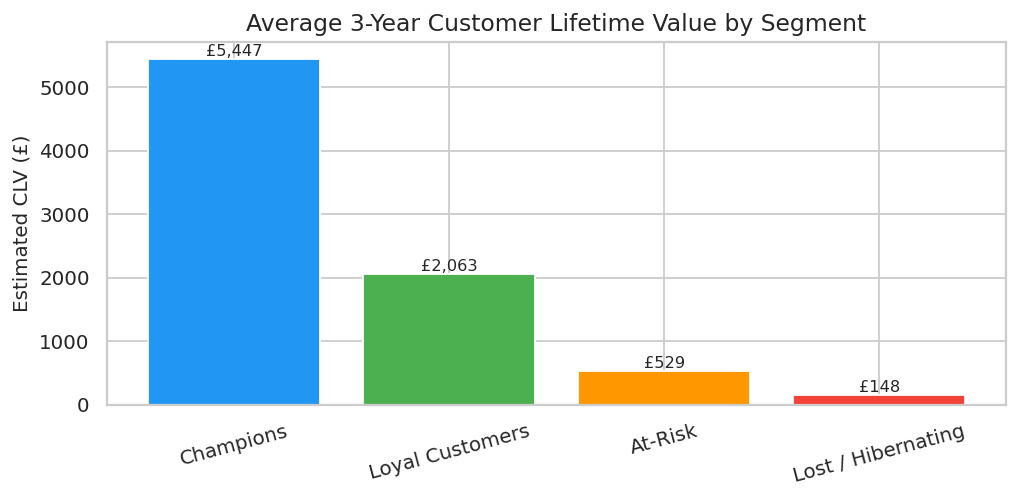


📌 Champions have a 3-year CLV that is orders of magnitude higher than Lost/Hibernating customers. Every pound spent retaining a Champion has a far higher expected return than acquiring an equivalent new customer.


In [ ]:
# ── CLV calculation ────────────────────────────────────────────────────────────
# Observation window = 365 days; project 3 years
PROJ_YEARS = 3

clv = rfm.copy()
clv["Avg_Order_Value"]  = clv["Monetary"] / clv["Frequency"]
clv["Purchase_Rate_pa"] = clv["Frequency"]               # already annualised (1-yr data)
clv["CLV_3yr"]          = clv["Avg_Order_Value"] * clv["Purchase_Rate_pa"] * PROJ_YEARS

clv_by_seg = clv.groupby("Segment").agg(
    Avg_CLV_3yr = ("CLV_3yr", "mean"),
    Total_CLV_3yr = ("CLV_3yr", "sum"),
).round(0).sort_values("Avg_CLV_3yr", ascending=False)

print(f"=== Estimated 3-Year CLV by Segment ===")
print(clv_by_seg.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(clv_by_seg.index, clv_by_seg["Avg_CLV_3yr"],
              color=[palette.get(s, "grey") for s in clv_by_seg.index])
ax.set_title("Average 3-Year Customer Lifetime Value by Segment")
ax.set_ylabel("Estimated CLV (£)")
ax.tick_params(axis="x", rotation=15)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"£{bar.get_height():,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig10_clv_by_segment.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n📌 Champions have a 3-year CLV that is orders of magnitude higher than "
      "Lost/Hibernating customers. Every pound spent retaining a Champion has a "
      "far higher expected return than acquiring an equivalent new customer.")


## Bonus 2 — Time-Series Segment Shift

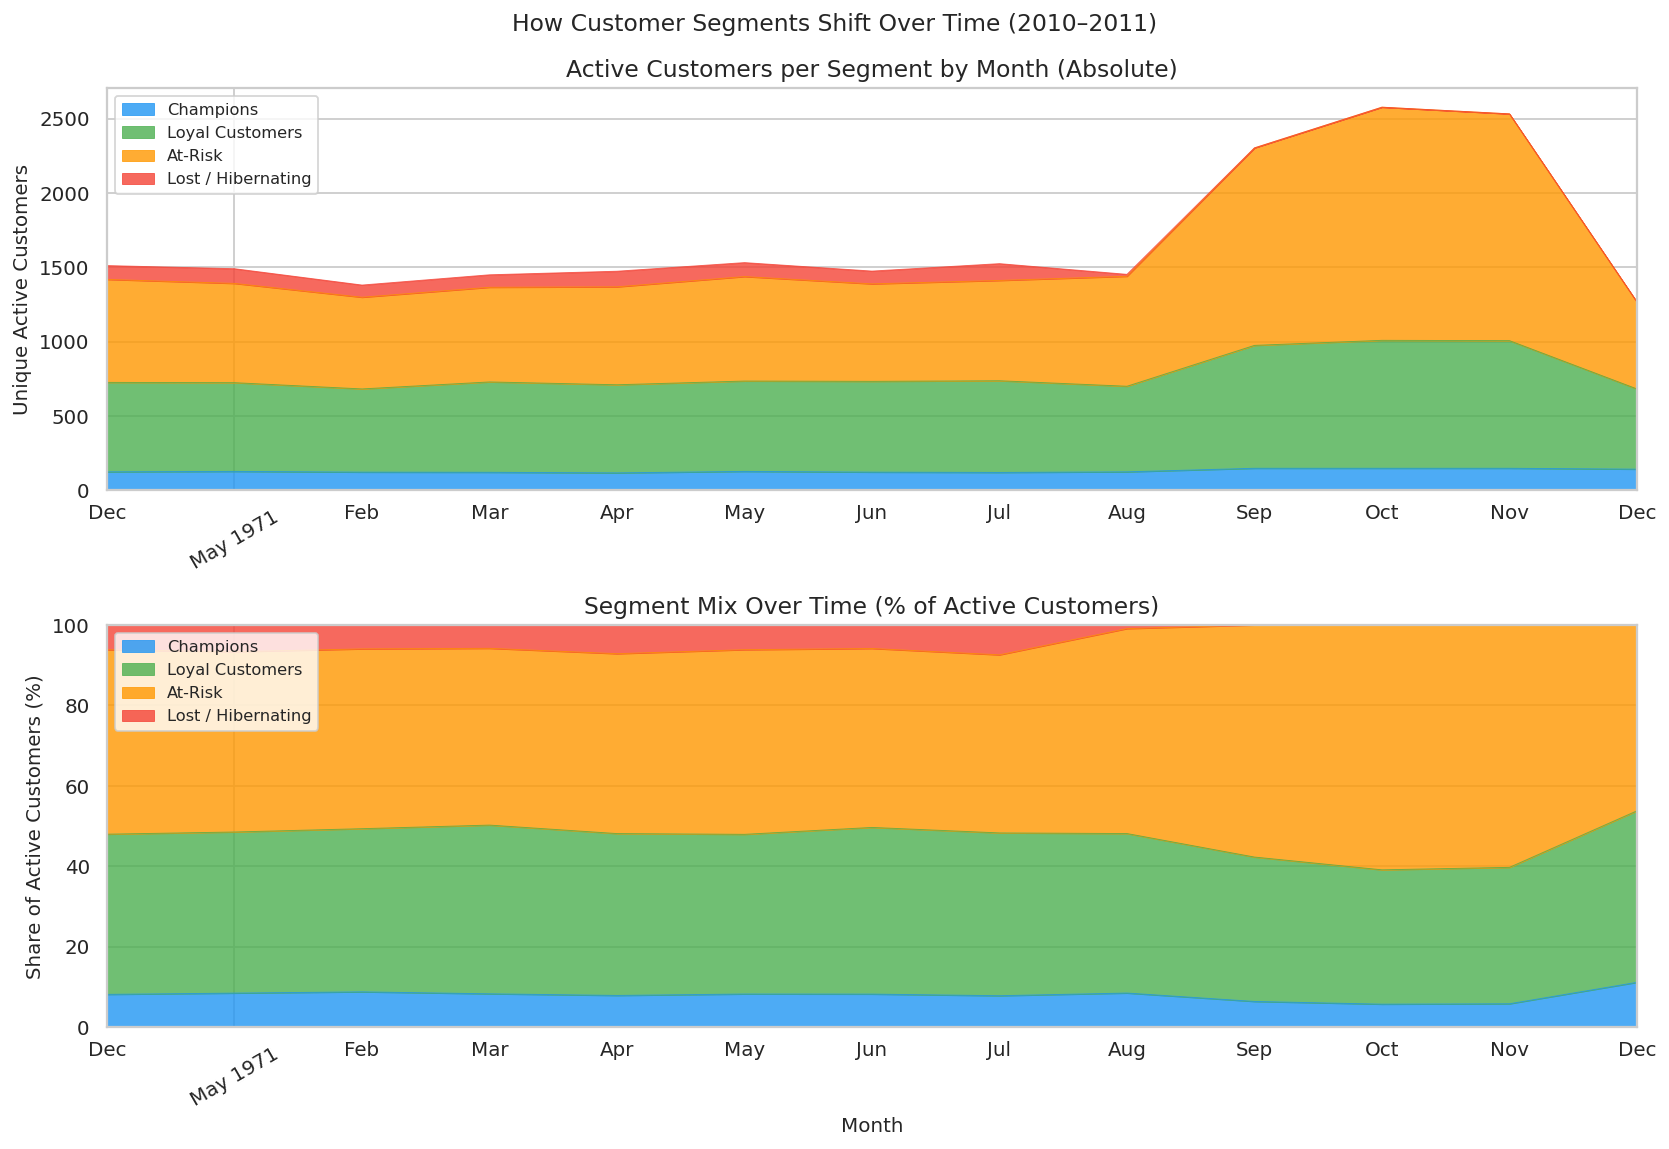

Champions — month-over-month active customer change:
  Jan 2011: ▲ 2.4%
  Feb 2011: ▼ 4.0%
  Mar 2011: ▼ 0.8%
  Apr 2011: ▼ 3.3%
  May 2011: ▲ 8.6%
  Jun 2011: ▼ 4.0%
  Jul 2011: ▼ 1.7%
  Aug 2011: ▲ 3.4%
  Sep 2011: ▲ 19.5%
  Oct 2011: ▲ 0.0%
  Nov 2011: ▲ 0.0%
  Dec 2011: ▼ 4.1%

📌 Interpretation: The stacked area chart shows how the customer mix evolves
   each month. A growing Champions share indicates improving retention.
   A rising At-Risk / Lost share is an early warning signal for churn.
   Note: since all customers are assigned a single final segment label,
   this view shows WHEN each segment was active — not segment transitions.


In [ ]:
# ── Bonus: How do segments shift over time? ──────────────────────────────────
# Strategy: assign each customer their segment, then look at WHEN they were
# active each month. This shows how the active customer mix evolves over 2010-2011.

# Build a month × customer activity table
df_monthly = df_with_segments.copy()
df_monthly["YearMonth"] = df_monthly["InvoiceDate"].dt.to_period("M")

# Count unique active customers per segment per month
monthly_seg = (
    df_monthly.groupby(["YearMonth", "Segment"])["CustomerID"]
    .nunique()
    .reset_index()
    .rename(columns={"CustomerID": "ActiveCustomers"})
)

monthly_seg["YearMonth_dt"] = monthly_seg["YearMonth"].dt.to_timestamp()

# ── Plot 1: Stacked area — absolute active customers ─────────────────────────
seg_order = ["Champions", "Loyal Customers", "At-Risk", "Lost / Hibernating"]
pivot = (
    monthly_seg.pivot(index="YearMonth_dt", columns="Segment", values="ActiveCustomers")
    .fillna(0)
    .reindex(columns=seg_order)
)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Stacked area
pivot.plot(
    kind="area",
    stacked=True,
    ax=axes[0],
    color=[palette[s] for s in seg_order],
    alpha=0.8,
    linewidth=0.5,
)
axes[0].set_title("Active Customers per Segment by Month (Absolute)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Unique Active Customers")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
axes[0].tick_params(axis="x", rotation=30)

# ── Plot 2: 100% stacked — relative mix shift ─────────────────────────────────
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(
    kind="area",
    stacked=True,
    ax=axes[1],
    color=[palette[s] for s in seg_order],
    alpha=0.8,
    linewidth=0.5,
)
axes[1].set_title("Segment Mix Over Time (% of Active Customers)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Share of Active Customers (%)")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("How Customer Segments Shift Over Time (2010–2011)", fontsize=13)
plt.tight_layout()
plt.savefig("fig11_segment_shift_over_time.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Month-over-month change for Champions ─────────────────────────────────────
champ_monthly = pivot["Champions"]
champ_pct_change = champ_monthly.pct_change() * 100

print("Champions — month-over-month active customer change:")
for month, chg in champ_pct_change.dropna().items():
    direction = "▲" if chg >= 0 else "▼"
    print(f"  {month.strftime('%b %Y')}: {direction} {abs(chg):.1f}%")

print("\n📌 Interpretation: The stacked area chart shows how the customer mix evolves")
print("   each month. A growing Champions share indicates improving retention.")
print("   A rising At-Risk / Lost share is an early warning signal for churn.")
print("   Note: since all customers are assigned a single final segment label,")
print("   this view shows WHEN each segment was active — not segment transitions.")

##Bonus 3 — Next Best Action Recommendation System

=== Next Best Action — Distribution ===

           Segment                 Action  Customers
           At-Risk      Win-Back Campaign       1369
           At-Risk Reactivation Incentive       1071
         Champions     VIP Loyalty Reward        147
Lost / Hibernating      Low-Cost Re-touch        504
Lost / Hibernating      High-Value Rescue         27
   Loyal Customers       Nurture & Deepen        681
   Loyal Customers    Re-engagement Nudge        195


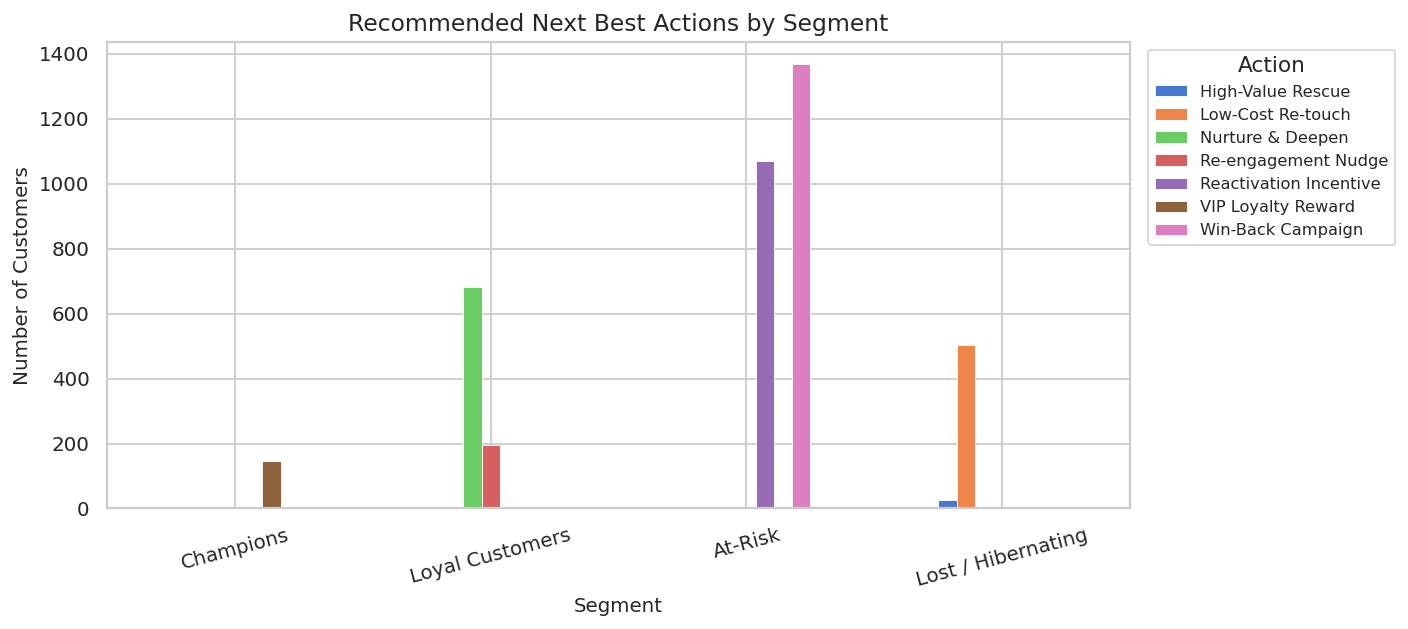


✅  rfm_nba.csv saved — 3,994 customers with personalised actions

=== Sample Recommendations (3 per segment) ===

── Champions ──
  Customer C17027 | R=5 F=5 M=5 | Action: VIP Loyalty Reward
    → Send an exclusive early-access invitation to new product lines with a personalised thank-you from the account manager.
  Customer C17032 | R=4 F=5 M=5 | Action: VIP Loyalty Reward
    → Send an exclusive early-access invitation to new product lines with a personalised thank-you from the account manager.
  Customer C17038 | R=5 F=5 M=5 | Action: VIP Loyalty Reward
    → Send an exclusive early-access invitation to new product lines with a personalised thank-you from the account manager.

── Loyal Customers ──
  Customer C17003 | R=5 F=4 M=4 | Action: Nurture & Deepen
    → Send a 'You might also love...' email based on past purchases to encourage cross-category exploration.
  Customer C17011 | R=4 F=5 M=5 | Action: Nurture & Deepen
    → Send a 'You might also love...' email based on past pur

In [ ]:
# ── Bonus: Next Best Action (NBA) Recommendation System ──────────────────────
# Rule-based system: each customer gets a personalised recommended action
# based on their Segment + RFM sub-scores.

# ── Step 1: RFM quintile scoring (1–5 per dimension) ─────────────────────────
rfm_nba = rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Segment"]].copy()

# Recency: lower is better → reverse rank (rank 5 = most recent)
rfm_nba["R_score"] = pd.qcut(rfm_nba["Recency"], q=5,
                              labels=[5, 4, 3, 2, 1]).astype(int)
# Frequency & Monetary: higher is better
rfm_nba["F_score"] = pd.qcut(rfm_nba["Frequency"].rank(method="first"), q=5,
                              labels=[1, 2, 3, 4, 5]).astype(int)
rfm_nba["M_score"] = pd.qcut(rfm_nba["Monetary"].rank(method="first"), q=5,
                              labels=[1, 2, 3, 4, 5]).astype(int)

rfm_nba["RFM_score"] = rfm_nba["R_score"] + rfm_nba["F_score"] + rfm_nba["M_score"]

# ── Step 2: Action rule engine ────────────────────────────────────────────────
def recommend_action(row):
    seg   = row["Segment"]
    r, f, m = row["R_score"], row["F_score"], row["M_score"]

    if seg == "Champions":
        if m == 5:
            return ("VIP Loyalty Reward",
                    "Send an exclusive early-access invitation to new product lines "
                    "with a personalised thank-you from the account manager.")
        else:
            return ("Upsell to Premium",
                    "Offer a curated bundle of your highest-margin products at a "
                    "10% loyalty discount to increase basket size.")

    elif seg == "Loyal Customers":
        if r >= 4:
            return ("Nurture & Deepen",
                    "Send a 'You might also love...' email based on past purchases "
                    "to encourage cross-category exploration.")
        else:
            return ("Re-engagement Nudge",
                    "Trigger a 'We miss you' email with a time-limited 15% discount "
                    "valid for 7 days to bring them back.")

    elif seg == "At-Risk":
        if f >= 3:
            return ("Win-Back Campaign",
                    "Send a personalised win-back offer: 'Here's what's new since "
                    "your last visit' + a 20% discount expiring in 14 days.")
        else:
            return ("Reactivation Incentive",
                    "Offer free shipping on next order plus a product spotlight "
                    "email matching their previous purchase category.")

    else:  # Lost / Hibernating
        if m >= 3:
            return ("High-Value Rescue",
                    "Assign to a sales rep for a personal outreach call. "
                    "Offer a bespoke wholesale pricing review to re-engage.")
        else:
            return ("Low-Cost Re-touch",
                    "Add to a low-frequency drip campaign (1 email/month). "
                    "If no response in 90 days, suppress to reduce list cost.")

rfm_nba[["Action", "Action_Detail"]] = rfm_nba.apply(
    recommend_action, axis=1, result_type="expand"
)

# ── Step 3: Summary table ─────────────────────────────────────────────────────
print("=== Next Best Action — Distribution ===\n")
action_summary = (
    rfm_nba.groupby(["Segment", "Action"])
    .size()
    .reset_index(name="Customers")
    .sort_values(["Segment", "Customers"], ascending=[True, False])
)
print(action_summary.to_string(index=False))

# ── Step 4: Visualise action distribution ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

action_counts = rfm_nba.groupby(["Segment", "Action"]).size().unstack(fill_value=0)
action_counts = action_counts.reindex(
    [s for s in seg_order if s in action_counts.index]
)
action_counts.plot(kind="bar", ax=ax, edgecolor="white", linewidth=0.5)

ax.set_title("Recommended Next Best Actions by Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Action", fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig12_next_best_action.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Step 5: Export enriched table ─────────────────────────────────────────────
nba_export = rfm_nba[["CustomerID", "Segment", "R_score", "F_score",
                        "M_score", "RFM_score", "Action", "Action_Detail"]]
nba_export.to_csv("rfm_nba.csv", index=False)
print(f"\n✅  rfm_nba.csv saved — {len(nba_export):,} customers with personalised actions")

# ── Step 6: Sample recommendations ────────────────────────────────────────────
print("\n=== Sample Recommendations (3 per segment) ===\n")
for seg in seg_order:
    sample = rfm_nba[rfm_nba["Segment"] == seg].head(3)
    print(f"── {seg} ──")
    for _, row in sample.iterrows():
        print(f"  Customer {row['CustomerID']} | R={row['R_score']} F={row['F_score']} "
              f"M={row['M_score']} | Action: {row['Action']}")
        print(f"    → {row['Action_Detail']}")
    print()

print("📌 Interpretation: The NBA system moves RetailGlobe from one-size-fits-all")
print("   blasts to 8 distinct, rule-based actions. Champions receive reward-focused")
print("   messages; At-Risk customers receive urgency-driven win-back offers.")
print("   The rfm_nba.csv export can be fed directly into any email marketing tool")
print("   (Mailchimp, Klaviyo, etc.) using the Action column as a campaign filter.")

---
## Summary & Next Steps

| Phase | Status |
|-------|--------|
| ✅ Data Engineering | Clean DataFrame, 5 cleaning steps documented |
| ✅ EDA | 5 visualisations with interpretations |
| ✅ RFM + K-Means | 4 named segments, elbow + silhouette analysis |
| ✅ Export | `online_retail_segmented.csv` ready for Power BI |
| ✅ Executive Summary | Saved to `executive_summary.md` |
| ✅ Bonus: CLV | 3-year CLV estimated per segment |

**Files produced:**
- `online_retail_segmented.csv` — full transactions with segment labels
- `rfm_table.csv` — one row per customer with R, F, M, Segment
- `executive_summary.md` — board-ready summary
- `fig1_*.png` through `fig10_*.png` — all chart exports
